In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis
)
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import (
    MinMaxScaler,
    StandardScaler
)

In [2]:
df = pd.DataFrame({
    'A':[10,20,30,40,50],
    'B':[5,15,25,35,45]
})
df

,A,B
0,10,5
1,20,15
2,30,25
3,40,35
4,50,45


In [5]:
df = pd.DataFrame({
    'A':[10,20,30,40,50],
    'B':[5,15,25,35,45]
})
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(df)
normalized_df = pd.DataFrame(
    normalized_data,
    columns=df.columns
)
normalized_df

,A,B
0,0.00,0.00
1,0.25,0.25
2,0.50,0.50
3,0.75,0.75
4,1.00,1.00


In [7]:
df = pd.DataFrame({
    'A':[10,20,30,40,50],
    'B':[5,15,25,35,45]
})
scaler = StandardScaler()
standardized_data = scaler.fit_transform(df)
standardized_df = pd.DataFrame(
    standardized_data,
    columns=df.columns
)
standardized_df

,A,B
0,-1.414214,-1.414214
1,-0.707107,-0.707107
2,0.000000,0.000000
3,0.707107,0.707107
4,1.414214,1.414214


In [8]:
df = pd.DataFrame({
    'Color':['Red','Blue','Green','Red','Blue']
})
df

,Color
0,Red
1,Blue
2,Green
3,Red
4,Blue


In [9]:
one_hot = pd.get_dummies(
    df,
    columns=['Color']
)
one_hot

,Color_Blue,Color_Green,Color_Red
0,False,False,True
1,True,False,False
2,False,True,False
3,False,False,True
4,True,False,False


In [13]:
df = pd.read_csv("/content/drive/MyDrive/Datasets(Data Science)/tips.csv")
df.head()
numeric_cols = df.select_dtypes(
    include=['float64','int64']
).columns
scaler_minmax = MinMaxScaler()
df_normalized = df.copy()
df_normalized[numeric_cols] = (
    scaler_minmax.fit_transform(
        df[numeric_cols]
    )
)
df_normalized.head()
scaler_standard = StandardScaler()
df_standardized = df.copy()
df_standardized[numeric_cols] = (
    scaler_standard.fit_transform(
        df[numeric_cols]
    )
)
df_standardized.head()
df_onehot = pd.get_dummies(
    df,
    columns=[
        'sex',
        'smoker',
        'day',
        'time'
    ]
)
df_onehot.head()

,total_bill,tip,size,price_per_person,Payer Name,CC Number,Payment ID,sex_Female,sex_Male,smoker_No,smoker_Yes,day_Fri,day_Sat,day_Sun,day_Thur,time_Dinner,time_Lunch
0,16.99,1.01,2,8.49,Christy Cunningham,3560325168603410,Sun2959,True,False,True,False,False,False,True,False,True,False
1,10.34,1.66,3,3.45,Douglas Tucker,4478071379779230,Sun4608,False,True,True,False,False,False,True,False,True,False
2,21.01,3.50,3,7.00,Travis Walters,6011812112971322,Sun4458,False,True,True,False,False,False,True,False,True,False
3,23.68,3.31,2,11.84,Nathaniel Harris,4676137647685994,Sun5260,False,True,True,False,False,False,True,False,True,False
4,24.59,3.61,4,6.15,Tonya Carter,4832732618637221,Sun2251,True,False,True,False,False,False,True,False,True,False


In [24]:
df = pd.read_csv("/content/drive/MyDrive/Datasets(Data Science)/tips.csv")
numeric_cols = df.select_dtypes(
    include=['float64','int64']
).columns
scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    df[numeric_cols]
)

standardized_df_new = pd.DataFrame(
    scaled_data,
    columns=numeric_cols
)
standardized_df_new

,total_bill,tip,size,price_per_person,CC Number
0,-0.314711,-1.439947,-0.600193,0.206929,0.421585
1,-1.063235,-0.969205,0.453383,-1.526068,0.809724
2,0.137780,0.363356,0.453383,-0.305405,1.458383
3,0.438315,0.225754,-0.600193,1.358822,0.893491
4,0.540745,0.443020,1.506958,-0.597677,0.959719
...,...,...,...,...,...
239,1.040511,2.115963,0.453383,0.616109,1.155676
240,0.832275,-0.722971,-0.600193,1.960557,0.398951
241,0.324630,-0.722971,-0.600193,1.186898,1.458416
242,-0.221287,-0.904026,-0.600193,0.351346,-1.082319


In [25]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(
    scaled_data
)

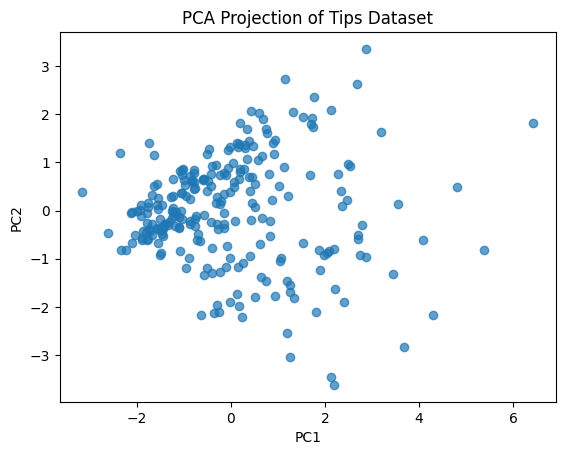

In [28]:
pca_df = pd.DataFrame(
    data = pca_result,
    columns = ['PC1', 'PC2']
)

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    alpha=0.7
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(
    "PCA Projection of Tips Dataset"
)
plt.show()

In [31]:
iris = load_iris()
X = iris.data
y = iris.target
lda = LinearDiscriminantAnalysis(
    n_components=2
)
X_lda = lda.fit_transform(X,y)
lda_df = pd.DataFrame(
    X_lda,
    columns=['LD1','LD2']
)
lda_df['target'] = y
print(
    "Explained Variance Ratio:",
    lda.explained_variance_ratio_
)
lda_df.head()

Explained Variance Ratio: [0.9912126 0.0087874]


,LD1,LD2,target
0,8.061800,-0.300421,0
1,7.128688,0.786660,0
2,7.489828,0.265384,0
3,6.813201,0.670631,0
4,8.132309,-0.514463,0


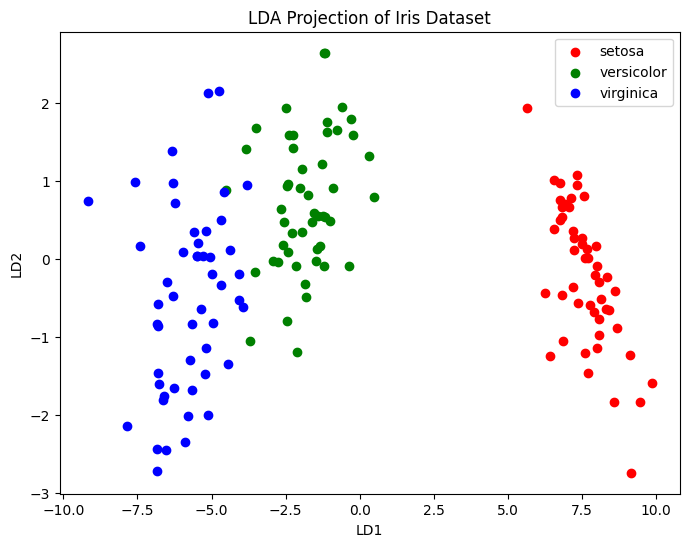

In [32]:
plt.figure(figsize=(8,6))

for label, color in zip(
    [0,1,2],
    ['red','green','blue']
):
    plt.scatter(
        lda_df.loc[
            lda_df['target']==label,
            'LD1'
        ],
        lda_df.loc[
            lda_df['target']==label,
            'LD2'
        ],
        label=iris.target_names[label],
        color=color
    )
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.title(
    'LDA Projection of Iris Dataset'
)
plt.legend()
plt.show()